### 02.DataLoader

In [226]:
import sys
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import polars as pl
from pprint import pprint 

In [316]:
# Notebookの作業ディレクトリを基準にパスを追加
project_root = Path.cwd()
sys.path.append(str(project_root / "src"))

from myfunctions import detect_os, windows_to_wsl_path, check_config_paths

#check OS
print(f"isOS: {detect_os()}")

# RootDirectory
PROJECT_ROOT = windows_to_wsl_path(r"C:\Users\yohei\Desktop\physionet-ecg-image-digitization")
#PROJECT_ROOT = Path("/Users/yohe/Desktop/physionet-ecg-image-digitization")
print(f"isPath :{PROJECT_ROOT.exists()}")
# directorys data
list(PROJECT_ROOT.glob("*"))

ImportError: cannot import name 'check_config_paths' from 'myfunctions' (/home/yohehe/projects/ECG-Analysis/src/myfunctions.py)

In [317]:
class CONFIG:
    train_csv_path = PROJECT_ROOT / "train.csv"
    test_csv_path = PROJECT_ROOT / "test.csv"
    sample_submission_csv_path = PROJECT_ROOT / "sample_submission.parquet"
    train_data_dir = PROJECT_ROOT / "train"
    test_data_dir = PROJECT_ROOT / "test"

In [318]:
# CONFIGで設定したPathの確認
def check_config_paths(config_class):
    missing = []
    for attr in dir(config_class):
        if attr.startswith("_"):
            continue
        value = getattr(config_class, attr)
        if isinstance(value, Path):
            if not value.exists():
                missing.append((attr, value))
    if missing:
        print("以下のパスが存在しません:")
        for name, path in missing:
            print(f" - {name}: {path}")
    else:
        print("すべてのパスが存在します")

# 使用例
check_config_paths(CONFIG)


すべてのパスが存在します


DataFrame

In [319]:
import polars as pl
train_df = pl.read_csv(CONFIG.train_csv_path)
train_df = train_df.to_pandas()
#普通に動くね。なんで？

### 各データフォルダの構成

In [320]:
sample_id = str(train_df["id"][0])
sample_fs = str(train_df["fs"][0])
sample_sig_len = train_df[train_df['id'] == int(sample_id)]['sig_len'].values[0]

print(sample_id)
print(sample_fs)
print(sample_sig_len)

7663343
500
5000


In [321]:
#set sampleID
sample_id = str(train_df["id"][0])
print(sample_id)

#directory
sample_data_dir = CONFIG.train_data_dir / sample_id
print("sample Dir Exist:",sample_data_dir.exists())

# datalist
sample_data_path_list = list(sample_data_dir.glob("*"))
pprint(sample_data_path_list)

7663343
sample Dir Exist: True
[PosixPath('/mnt/c/Users/yohei/Desktop/physionet-ecg-image-digitization/train/7663343/7663343-0001.png'),
 PosixPath('/mnt/c/Users/yohei/Desktop/physionet-ecg-image-digitization/train/7663343/7663343-0003.png'),
 PosixPath('/mnt/c/Users/yohei/Desktop/physionet-ecg-image-digitization/train/7663343/7663343-0004.png'),
 PosixPath('/mnt/c/Users/yohei/Desktop/physionet-ecg-image-digitization/train/7663343/7663343-0005.png'),
 PosixPath('/mnt/c/Users/yohei/Desktop/physionet-ecg-image-digitization/train/7663343/7663343-0006.png'),
 PosixPath('/mnt/c/Users/yohei/Desktop/physionet-ecg-image-digitization/train/7663343/7663343-0009.png'),
 PosixPath('/mnt/c/Users/yohei/Desktop/physionet-ecg-image-digitization/train/7663343/7663343-0010.png'),
 PosixPath('/mnt/c/Users/yohei/Desktop/physionet-ecg-image-digitization/train/7663343/7663343-0011.png'),
 PosixPath('/mnt/c/Users/yohei/Desktop/physionet-ecg-image-digitization/train/7663343/7663343-0012.png'),
 PosixPath('/mn

#csv

In [322]:
sample_data_csv = CONFIG.train_data_dir / sample_id / f"{sample_id}.csv"
print("sample Dir Exist:",sample_data_csv.exists())

sample Dir Exist: True


### DATA

In [323]:
def load_ecg_data_by_id(ecg_id, train_df, config) -> dict:
    row = train_df[train_df["id"] == int(ecg_id)]
    if row.empty:
        raise ValueError(f"ID {ecg_id} が train_df に存在しません")

    fs = float(row["fs"].values[0])
    sig_len = int(row["sig_len"].values[0])
    csv_path = list((config.train_data_dir / str(ecg_id)).glob("*.csv"))[0]
    ecg_df = pd.read_csv(csv_path)

    return {
        "id": str(ecg_id),
        "fs": fs,
        "sig_len": sig_len,
        "duration_sec": sig_len / fs,
        "csv_path": csv_path,
        "ecg_df": ecg_df
    }

In [324]:
def extract_lead_features(ecg_dict: dict) -> dict:
    ecg_df = ecg_dict["ecg_df"]
    lead_names = ['I', 'II', 'III', 'aVR', 'aVL', 'aVF',
                  'V1', 'V2', 'V3', 'V4', 'V5', 'V6']

    lead_stats = {}
    flat_row = {}

    for lead in lead_names:
        series = pd.to_numeric(ecg_df[lead], errors="coerce").dropna()
        stats = {
            "mean": series.mean(),
            "std": series.std(),
            "min": series.min(),
            "max": series.max(),
            "median": series.median(),
        }
        lead_stats[lead] = stats

        # フラットな特徴量名で展開（例：V1_mean, V1_std, ...）
        for stat_name, value in stats.items():
            flat_row[f"{lead}_{stat_name}"] = value

    ecg_dict["lead_stats"] = lead_stats
    ecg_dict["features_row"] = flat_row
    return ecg_dict


In [325]:
def plot_ecg_waveform(ecg_dict: dict, plot_leads: list[str] = None):
    ecg_df = ecg_dict["ecg_df"]
    fs = ecg_dict["fs"]
    ecg_id = ecg_dict["id"]

    all_leads = ['I', 'II', 'III', 'aVR', 'aVL', 'aVF',
                 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
    plot_leads = plot_leads or all_leads

    time_axis = np.arange(len(ecg_df)) / fs
    fig, axes = plt.subplots(len(plot_leads), 1, figsize=(20, 1.5 * len(plot_leads)), sharex=True)
    fig.suptitle(f'🫀 ECG Waveform - ID: {ecg_id} (fs={fs:.1f} Hz)', fontsize=18, fontweight='bold', y=0.995)

    for ax, lead in zip(axes, plot_leads):
        if lead not in ecg_df.columns:
            continue
        ecg_df[lead] = pd.to_numeric(ecg_df[lead], errors="coerce")
        ax.plot(time_axis, ecg_df[lead], color='black', linewidth=1.2, alpha=0.9)
        ax.fill_between(time_axis, ecg_df[lead], alpha=0.1, color='gray')
        ax.set_ylabel(lead, fontsize=13, fontweight='bold', rotation=0, ha='right', va='center')
        ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
        ax.set_xlim(0, len(ecg_df) / fs)
        ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5, alpha=0.5)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

        stats = ecg_dict.get("lead_stats", {}).get(lead, {})
        if stats:
            ax.text(0.02, 0.95, f'μ={stats["mean"]:.3f}, σ={stats["std"]:.3f}',
                    transform=ax.transAxes, fontsize=9, verticalalignment='top',
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

    axes[-1].set_xlabel('Time (seconds)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [326]:
def process_ecg_by_id(
    ecg_id: int,
    train_df: pd.DataFrame,
    config,
    is_plot: bool = True,
    plot_leads: list[str] = None
) -> dict:
    ecg_dict = load_ecg_data_by_id(ecg_id, train_df, config)
    ecg_dict = extract_lead_features(ecg_dict)
    if is_plot:
        plot_ecg_waveform(ecg_dict, plot_leads)
    return ecg_dict

### image plot


In [327]:
train_df

,id,fs,sig_len
0,7663343,500,5000
1,10140238,1000,10000
2,11842146,1000,10000
3,19030958,250,2500
4,19585145,512,5120
...,...,...,...
972,4277555223,1000,10000
973,4283871417,256,2560
974,4284351157,512,5120
975,4289880010,500,5000


/tmp/ipykernel_7729/612745513.py:34: UserWarning: Glyph 129728 (\N{ANATOMICAL HEART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/yohehe/yohenv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129728 (\N{ANATOMICAL HEART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


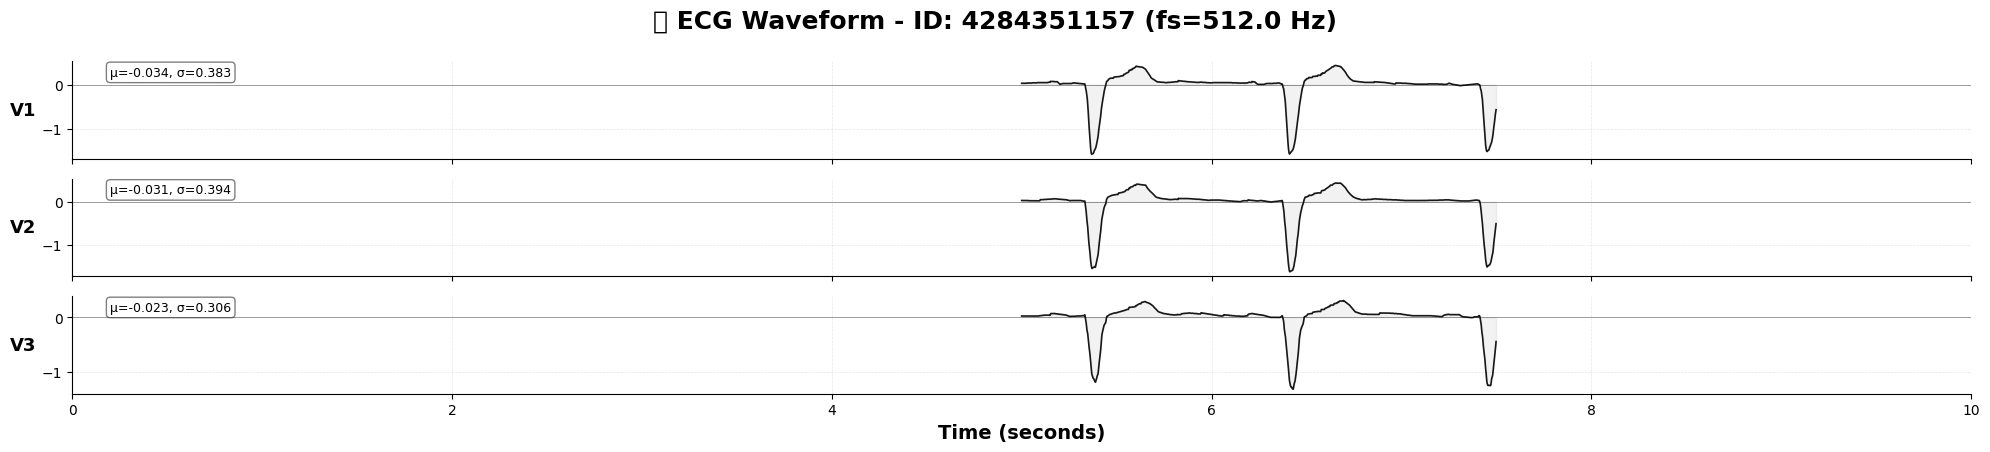

{'max': np.float64(0.434),
 'mean': np.float64(-0.03119453124999999),
 'median': np.float64(0.04),
 'min': np.float64(-1.614),
 'std': np.float64(0.3940343334676621)}


In [328]:
ecg_info = process_ecg_by_id(4284351157, train_df, CONFIG, is_plot=True, plot_leads=["V1", "V2", "V3"])
pprint(ecg_info["lead_stats"]["V2"])


In [329]:
ecg_info

{'id': '4284351157',
 'fs': 512.0,
 'sig_len': 5120,
 'duration_sec': 10.0,
 'csv_path': PosixPath('/mnt/c/Users/yohei/Desktop/physionet-ecg-image-digitization/train/4284351157/4284351157.csv'),
 'ecg_df':           I     II    III  aVR  aVL  aVF  V1  V2  V3     V4     V5     V6
 0     0.050  0.050  0.000  NaN  NaN  NaN NaN NaN NaN    NaN    NaN    NaN
 1     0.051  0.049 -0.001  NaN  NaN  NaN NaN NaN NaN    NaN    NaN    NaN
 2     0.048  0.050  0.001  NaN  NaN  NaN NaN NaN NaN    NaN    NaN    NaN
 3     0.051  0.049 -0.001  NaN  NaN  NaN NaN NaN NaN    NaN    NaN    NaN
 4     0.048  0.050  0.001  NaN  NaN  NaN NaN NaN NaN    NaN    NaN    NaN
 ...     ...    ...    ...  ...  ...  ...  ..  ..  ..    ...    ...    ...
 5115    NaN  0.079    NaN  NaN  NaN  NaN NaN NaN NaN  0.143 -0.014 -0.069
 5116    NaN  0.080    NaN  NaN  NaN  NaN NaN NaN NaN  0.146 -0.015 -0.070
 5117    NaN  0.079    NaN  NaN  NaN  NaN NaN NaN NaN  0.143 -0.014 -0.069
 5118    NaN  0.080    NaN  NaN  NaN  NaN NaN

In [330]:
ecg_info["ecg_df"]

,I,II,III,aVR,aVL,aVF,V1,V2,V3,V4,V5,V6
0,0.050,0.050,0.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.051,0.049,-0.001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.048,0.050,0.001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.051,0.049,-0.001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.048,0.050,0.001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
5115,NaN,0.079,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.143,-0.014,-0.069
5116,NaN,0.080,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.146,-0.015,-0.070
5117,NaN,0.079,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.143,-0.014,-0.069
5118,NaN,0.080,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.146,-0.015,-0.071


### DATASETの作成

In [348]:
import torch
from torch.utils.data import Dataset
import pandas as pd
import numpy as np

class ECGWaveformDataset(Dataset):
    def __init__(self, meta_df: pd.DataFrame, config, lead_names=None):
        """
        Parameters:
        - meta_df: メタ情報を含むDataFrame（id, fs, sig_len, labelなど）
        - config: CONFIGクラス（train_data_dirなど）
        - lead_names: 使用するリード名（Noneなら全12誘導）
        """
        self.meta_df = meta_df.reset_index(drop=True)
        self.config = config
        self.lead_names = lead_names or ['I', 'II', 'III', 'aVR', 'aVL', 'aVF',
                                         'V1', 'V2', 'V3', 'V4', 'V5', 'V6']

    def __len__(self):
        return len(self.meta_df)

    def __getitem__(self, idx):
        row = self.meta_df.iloc[idx]
        ecg_id = str(row["id"])

        # --- CSV読み込み ---
        csv_path = list((self.config.train_data_dir / ecg_id).glob("*.csv"))[0]
        ecg_df = pd.read_csv(csv_path)

        # --- リード抽出とTensor化 ---
        ecg_df = ecg_df[self.lead_names].astype(np.float32)
        ecg_array = ecg_df.to_numpy().T  # shape: (12, T)
        ecg_tensor = torch.from_numpy(ecg_array)  # NaNはそのまま保持

        # --- ラベル（任意） ---
        label = row.get("label", -1)

        return {
            "id": ecg_id,
            "ecg": ecg_tensor,  # shape: (12, T)
            "label": label
        }

In [349]:
def ecg_collate_fn(batch):
    return {
        "id": [item["id"] for item in batch],
        "label": torch.tensor([item["label"] for item in batch], dtype=torch.long),
        "ecg": [item["ecg"] for item in batch]  # list of [12, T_i] tensors
    }


In [350]:
from torch.utils.data import DataLoader

dataset = ECGWaveformDataset(meta_df=train_df, config=CONFIG)
loader = DataLoader(dataset, batch_size=8, shuffle=True, collate_fn=ecg_collate_fn)
batch = next(iter(loader))
#print(batch["ecg"].shape)    # torch.Size([8, 12, T])
#print(batch["label"])        # torch.Size([8])
#print(batch["id"])           # list of 8 IDs

In [351]:
batch

{'id': ['405307743',
  '1059602762',
  '3165279151',
  '145098200',
  '1709636457',
  '1257259783',
  '3485592327',
  '3174963235'],
 'label': tensor([-1, -1, -1, -1, -1, -1, -1, -1]),
 'ecg': [tensor([[-0.0100, -0.0100, -0.0090,  ...,     nan,     nan,     nan],
          [ 0.0200,  0.0170,  0.0200,  ...,  0.0420,  0.0400,  0.0300],
          [ 0.0300,  0.0270,  0.0300,  ...,     nan,     nan,     nan],
          ...,
          [    nan,     nan,     nan,  ..., -0.0510, -0.0440, -0.0220],
          [    nan,     nan,     nan,  ..., -0.0800, -0.0700, -0.0320],
          [    nan,     nan,     nan,  ..., -0.0470, -0.0450, -0.0340]]),
  tensor([[-0.0250, -0.0310, -0.0250,  ...,     nan,     nan,     nan],
          [ 0.0140,  0.0000,  0.0150,  ...,  0.1340,  0.1200,  0.0670],
          [ 0.0400,  0.0320,  0.0400,  ...,     nan,     nan,     nan],
          ...,
          [    nan,     nan,     nan,  ...,  0.0860,  0.0700,  0.0090],
          [    nan,     nan,     nan,  ...,  0.1910,  0.

In [352]:
### とりあえず出力まで

方針

[ECG画像] → Encoder(CNN/ViT) → 潜在ベクトル
        ↘ TripletLoss（類似性学習）
         ↘ Decoder(Transformer) → [12, T] 波形出力
                          ↘ MSELoss（波形復元）


✅ まとめ：おすすめ方針
- ✅ Encoder-Decoder構造は画像→波形のような非対称タスクに最適
- ✅ Foundationモデル（ResNet, ViTなど）をEncoderに使うことで精度・安定性・学習効率が向上
- ✅ DecoderはTransformer系で波形の時間構造を捉える設計が有効
- ✅ 自己教師あり（MAE, SimCLR）で事前学習してからFine-tuneするのも強力




## sample model

もちろんです、洋平さん。以下は、画像（224×224×3）を入力として、ECG波形（12リード × T時系列）を出力するための PyTorchベースのEncoder-Decoderモデルスケルトンです。
Encoderには事前学習済みのResNetを使い、DecoderにはTransformerを用いて時系列を生成する構成になっています。


In [353]:
import torch
import torch.nn as nn
import torchvision.models as models

class ECGImageToWaveformModel(nn.Module):
    def __init__(self, 
                 embed_dim=512, 
                 seq_len=1024, 
                 num_leads=12, 
                 transformer_layers=4, 
                 nhead=8):
        super().__init__()
        self.seq_len = seq_len
        self.num_leads = num_leads

        # --- Encoder: Pretrained ResNet Backbone ---
        resnet = models.resnet18(pretrained=True)
        self.encoder = nn.Sequential(*list(resnet.children())[:-2])  # Remove avgpool & fc
        self.conv_proj = nn.Conv2d(512, embed_dim, kernel_size=1)   # Project to embed_dim

        # --- Positional Encoding for Decoder ---
        self.pos_embed = nn.Parameter(torch.randn(seq_len, embed_dim))

        # --- Transformer Decoder ---
        decoder_layer = nn.TransformerDecoderLayer(d_model=embed_dim, nhead=nhead, batch_first=True)
        self.transformer_decoder = nn.TransformerDecoder(decoder_layer, num_layers=transformer_layers)

        # --- Output Projection ---
        self.output_proj = nn.Linear(embed_dim, num_leads)

    def forward(self, x_img):
        """
        x_img: (B, 3, 224, 224)
        Returns: (B, num_leads, seq_len)
        """
        B = x_img.size(0)

        # --- Encode Image ---
        x_feat = self.encoder(x_img)              # (B, 512, H', W')
        x_proj = self.conv_proj(x_feat)           # (B, embed_dim, H', W')
        x_proj = x_proj.flatten(2).transpose(1, 2)  # (B, N, embed_dim)

        # --- Prepare Decoder Input ---
        tgt = self.pos_embed.unsqueeze(0).repeat(B, 1, 1)  # (B, seq_len, embed_dim)

        # --- Decode Sequence ---
        decoded = self.transformer_decoder(tgt, memory=x_proj)  # (B, seq_len, embed_dim)

        # --- Project to ECG Leads ---
        output = self.output_proj(decoded)        # (B, seq_len, num_leads)
        output = output.transpose(1, 2)           # (B, num_leads, seq_len)

        return output

✅ 入出力の形状
|  |  |  | 
| x_img | (B, 3, 224, 224) |  | 
| output | (B, 12, T) |  | 
| T | seq_len |  | 



✅ 拡張ポイント
- seq_len を可変にするには、pos_embed を動的生成に変更
- 欠損対応には mask を transformer_decoder に渡す
- output_proj を Conv1d にすれば、波形らしい滑らかな出力も可能
- TransformerDecoder を GRU や LSTM に置き換えることも可能




✅ 次のステップ
- 損失関数（MSE, Masked MSE）の設計
- Dataset から画像＋波形ペアを返す構造の整備
- モデルの事前学習（画像→波形復元）またはFine-tuning

このスケルトンは、画像から波形を生成するモデルのベースとして非常に拡張性があります。次は MaskedMSELoss や Dataset の構成を整えましょうか？それとも推論・可視化のテンプレートに進みますか？


### DATASETにマスクを付与する

In [354]:
import torch
from torch.utils.data import Dataset
import pandas as pd
import numpy as np

class ECGWaveformDataset(Dataset):
    def __init__(self, meta_df: pd.DataFrame, config, lead_names=None):
        """
        Parameters:
        - meta_df: メタ情報を含むDataFrame（id, labelなど）
        - config: CONFIGクラス（train_data_dirなど）
        - lead_names: 使用するリード名（Noneなら全12誘導）
        """
        self.meta_df = meta_df.reset_index(drop=True)
        self.config = config
        self.lead_names = lead_names or ['I', 'II', 'III', 'aVR', 'aVL', 'aVF',
                                         'V1', 'V2', 'V3', 'V4', 'V5', 'V6']

    def __len__(self):
        return len(self.meta_df)

    def __getitem__(self, idx):
        row = self.meta_df.iloc[idx]
        ecg_id = str(row["id"])

        # --- CSV読み込み ---
        csv_path = list((self.config.train_data_dir / ecg_id).glob("*.csv"))[0]
        ecg_df = pd.read_csv(csv_path)

        # --- リード抽出とTensor化 ---
        ecg_df = ecg_df[self.lead_names].astype(np.float32)
        ecg_array = ecg_df.to_numpy().T  # shape: (12, T)
        ecg_tensor = torch.from_numpy(ecg_array)  # NaNはそのまま保持

        # --- 欠損マスク（True: 有効値） ---
        mask_nan = ~torch.isnan(ecg_tensor)  # shape: (12, T)

        # --- 有効時間ステップ（1つでも有効値がある時間軸） ---
        mask_valid = mask_nan.any(dim=0)  # shape: (T,)

        # --- ラベル（任意） ---
        label = row.get("label", -1)

        return {
            "id": ecg_id,
            "ecg": ecg_tensor,        # (12, T)
            "mask_nan": mask_nan,     # (12, T)
            "mask_valid": mask_valid, # (T,)
            "length": ecg_tensor.shape[1],
            "label": label
        }

In [355]:
import torch
import torch.nn.functional as F

def ecg_collate_fn(batch, pad_value=0.0):
    batch_size = len(batch)
    num_leads = batch[0]["ecg"].shape[0]
    max_len = max(item["length"] for item in batch)

    ecg_padded = []
    mask_nan_padded = []
    mask_valid_padded = []

    for item in batch:
        ecg = item["ecg"]
        mask_nan = item["mask_nan"]
        mask_valid = item["mask_valid"]
        T = ecg.shape[1]
        pad_len = max_len - T

        ecg_pad = F.pad(ecg, (0, pad_len), value=pad_value)  # (12, max_len)
        mask_nan_pad = F.pad(mask_nan, (0, pad_len), value=False)  # (12, max_len)
        mask_valid_pad = F.pad(mask_valid, (0, pad_len), value=False)  # (max_len,)

        ecg_padded.append(ecg_pad)
        mask_nan_padded.append(mask_nan_pad)
        mask_valid_padded.append(mask_valid_pad)

    ecg_batch = torch.stack(ecg_padded)             # (B, 12, max_len)
    mask_nan_batch = torch.stack(mask_nan_padded)   # (B, 12, max_len)
    mask_valid_batch = torch.stack(mask_valid_padded)  # (B, max_len)

    labels = torch.tensor([item["label"] for item in batch], dtype=torch.long)
    ids = [item["id"] for item in batch]
    lengths = torch.tensor([item["length"] for item in batch], dtype=torch.long)

    return {
        "id": ids,
        "ecg": ecg_batch,               # (B, 12, max_len)
        "mask_nan": mask_nan_batch,    # (B, 12, max_len)
        "mask_valid": mask_valid_batch,  # (B, max_len)
        "length": lengths,             # (B,)
        "label": labels                # (B,)
    }

In [356]:
from torch.utils.data import DataLoader

dataset = ECGWaveformDataset(meta_df=train_df, config=CONFIG)
loader = DataLoader(dataset, batch_size=8, shuffle=True, collate_fn=ecg_collate_fn)

batch = next(iter(loader))
print(batch["ecg"].shape)         # torch.Size([8, 12, max_len])
print(batch["mask_nan"].shape)    # torch.Size([8, 12, max_len])
print(batch["mask_valid"].shape)  # torch.Size([8, max_len])


torch.Size([8, 12, 10250])
torch.Size([8, 12, 10250])
torch.Size([8, 10250])


### 出力できた！！みてみよ！

In [357]:
import torch
import torch.nn as nn

# --- モデル定義（前回のスケルトンを使う） ---
model = ECGImageToWaveformModel(seq_len=1024, num_leads=12)
model.eval()

# --- ランダム入力画像 ---
B = 4
x_img = torch.randn(B, 3, 224, 224)

# --- モデル出力（波形） ---
with torch.no_grad():
    pred_waveform = model(x_img)  # shape: (B, 12, 1024)

# --- ランダム教師波形（同サイズ） ---
target_waveform = torch.randn_like(pred_waveform)

# --- ランダムマスク（True: 有効） ---
mask_nan = torch.rand_like(pred_waveform) > 0.2  # 80%有効

# --- Masked MSE Loss 定義 ---
def masked_mse(pred, target, mask):
    diff = (pred - target) ** 2
    masked_diff = diff[mask]
    return masked_diff.mean()

# --- 損失計算 ---
loss = masked_mse(pred_waveform, target_waveform, mask_nan)
print(f"Masked MSE Loss: {loss.item():.4f}")

/home/yohehe/yohenv/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/yohehe/yohenv/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /home/yohehe/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:01<00:00, 32.9MB/s]


Masked MSE Loss: 1.4572


In [358]:
## 出力できてますね。

In [359]:
import torch
import torch.nn as nn
import torch.optim as optim

# --- モデル定義 ---
model = ECGImageToWaveformModel(seq_len=1024, num_leads=12)
model.train()

# --- Optimizer & Scheduler ---
optimizer = optim.Adam(model.parameters(), lr=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

# --- 損失関数（Masked MSE） ---
def masked_mse(pred, target, mask):
    diff = (pred - target) ** 2
    masked_diff = diff[mask]
    return masked_diff.mean()

# --- 学習ループ ---
num_epochs = 20
for epoch in range(num_epochs):
    total_loss = 0.0

    for batch in train_loader:
        x_img = batch["image"]             # (B, 3, 224, 224)
        target = batch["ecg"]              # (B, 12, T)
        mask_nan = batch["mask_nan"]       # (B, 12, T)

        optimizer.zero_grad()
        pred = model(x_img)                # (B, 12, T)

        loss = masked_mse(pred, target, mask_nan)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    scheduler.step()
    print(f"Epoch {epoch+1}/{num_epochs} - Loss: {total_loss:.4f}")

NameError: name 'train_loader' is not defined

In [360]:
model.eval()
val_loss = 0.0

with torch.no_grad():
    for batch in val_loader:
        x_img = batch["image"]             # (B, 3, 224, 224)
        target = batch["ecg"]              # (B, 12, T)
        mask_nan = batch["mask_nan"]       # (B, 12, T)

        pred = model(x_img)                # (B, 12, T)
        loss = masked_mse(pred, target, mask_nan)
        val_loss += loss.item()

avg_val_loss = val_loss / len(val_loader)
print(f"Validation Loss: {avg_val_loss:.4f}")

NameError: name 'val_loader' is not defined

In [361]:
import matplotlib.pyplot as plt

def plot_ecg_waveforms(pred, target=None, mask=None, lead_names=None, sample_idx=0):
    """
    Parameters:
    - pred: Tensor (B, 12, T) - モデル出力
    - target: Tensor (B, 12, T) - 教師波形（任意）
    - mask: Tensor (B, 12, T) - 欠損マスク（任意）
    - lead_names: list of str - リード名（任意）
    - sample_idx: int - 表示するバッチ内のインデックス
    """
    num_leads = pred.shape[1]
    T = pred.shape[2]
    lead_names = lead_names or ['I', 'II', 'III', 'aVR', 'aVL', 'aVF',
                                'V1', 'V2', 'V3', 'V4', 'V5', 'V6']

    fig, axes = plt.subplots(num_leads, 1, figsize=(12, 2 * num_leads), sharex=True)

    for i in range(num_leads):
        ax = axes[i]
        time = range(T)

        # --- モデル出力波形 ---
        ax.plot(time, pred[sample_idx, i].cpu().numpy(), label='Predicted', color='blue')

        # --- 教師波形（あれば） ---
        if target is not None:
            ax.plot(time, target[sample_idx, i].cpu().numpy(), label='Target', color='orange', alpha=0.6)

        # --- 欠損マスク（あれば） ---
        if mask is not None:
            valid = mask[sample_idx, i].cpu().numpy()
            ax.fill_between(time, -1, 1, where=~valid, color='gray', alpha=0.2, label='Masked')

        ax.set_ylabel(lead_names[i])
        ax.legend(loc='upper right')

    plt.xlabel("Time")
    plt.tight_layout()
    plt.show()

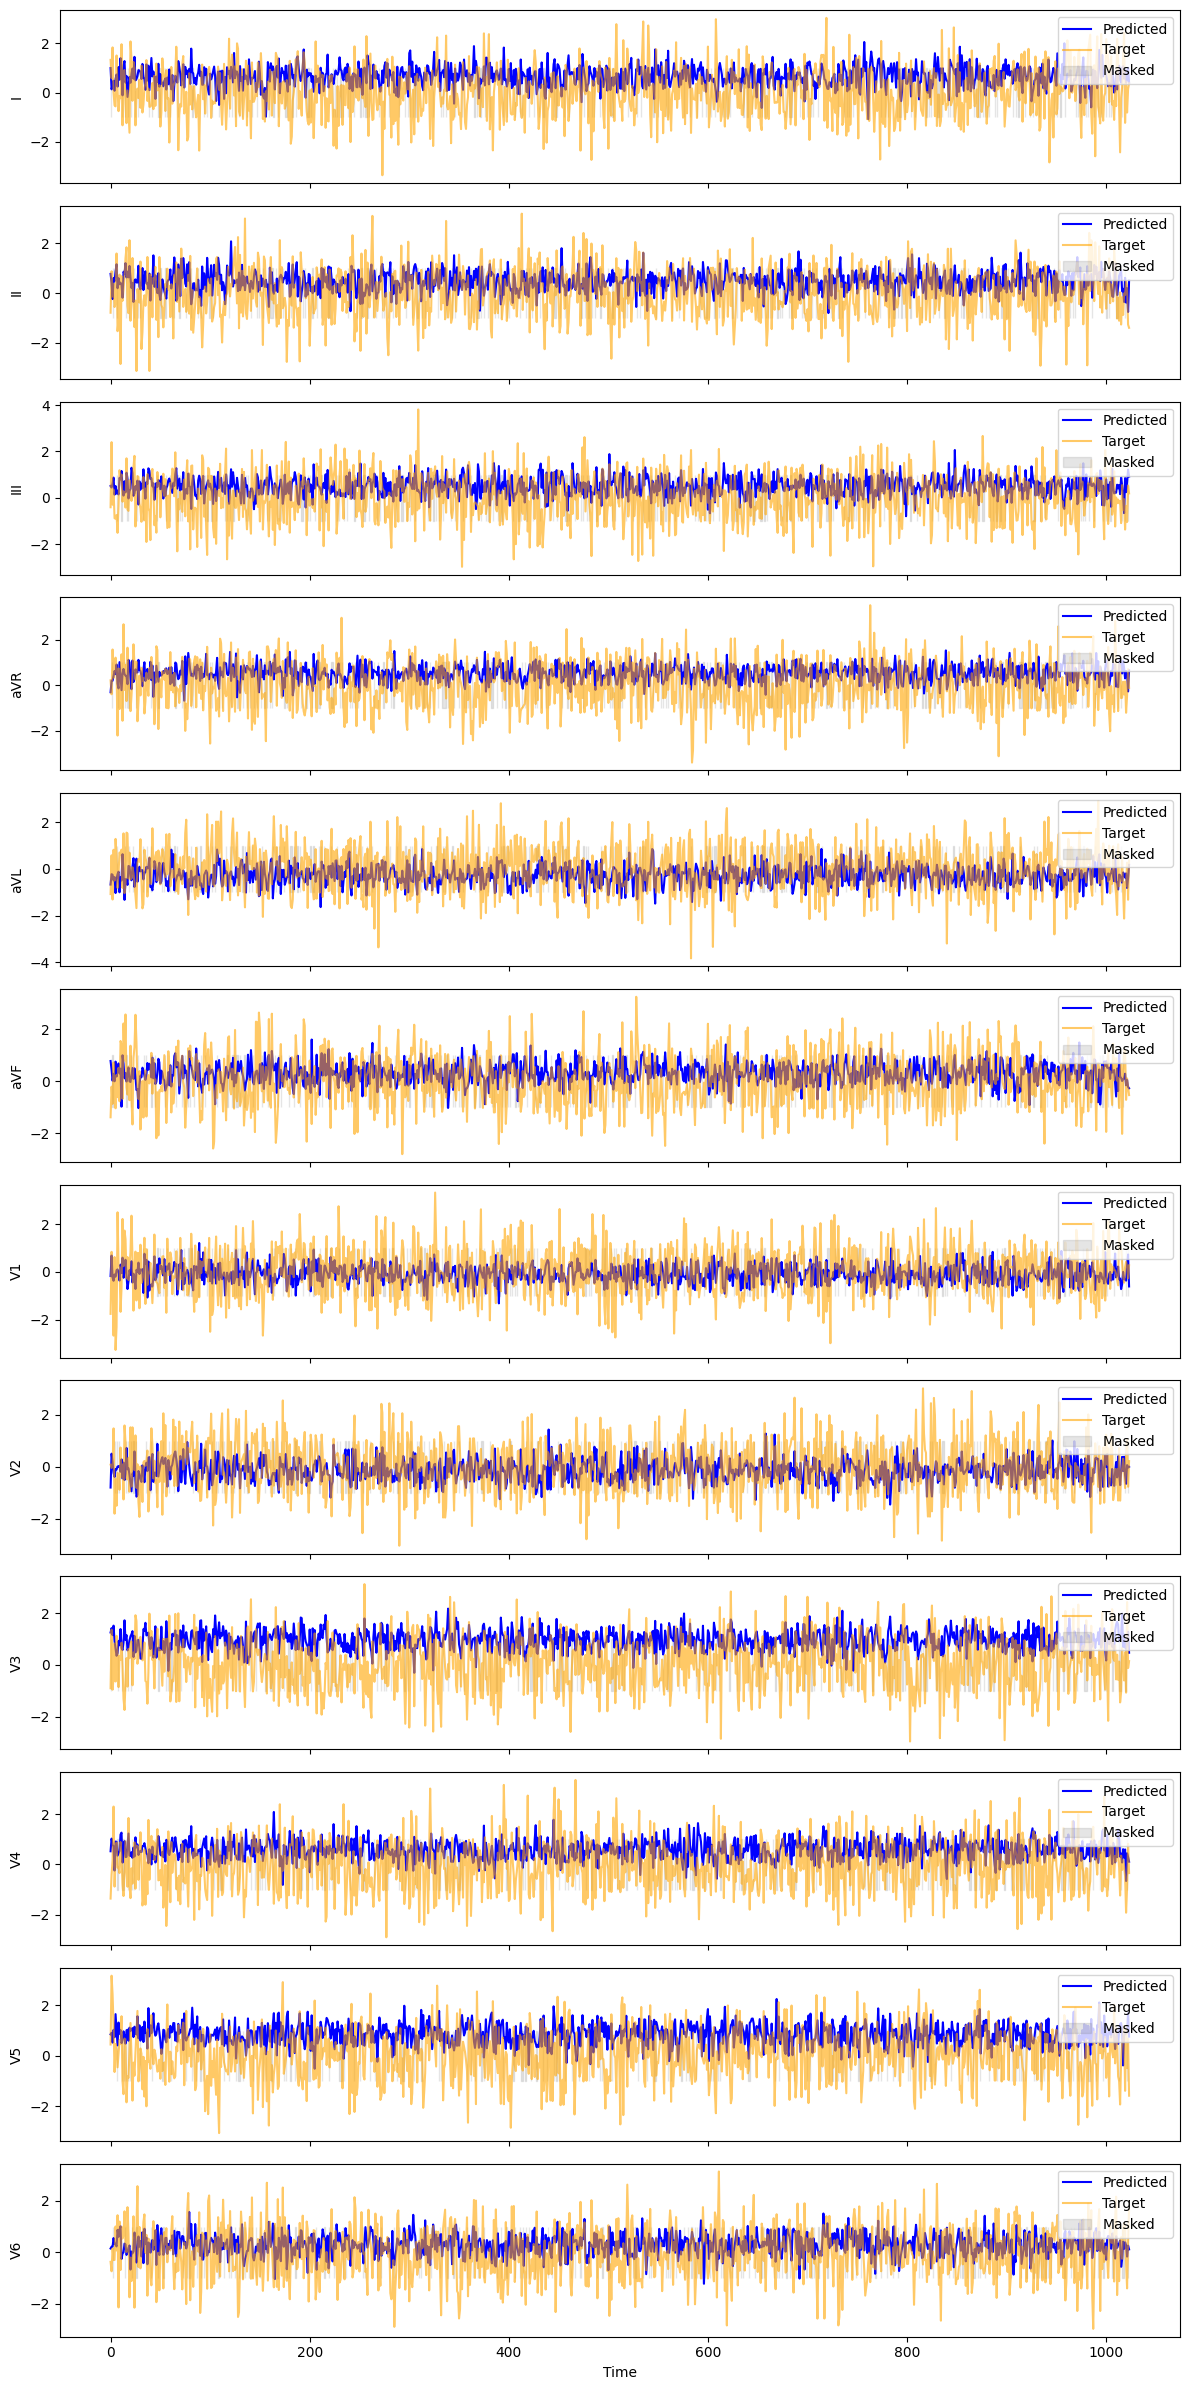

In [362]:
# pred_waveform: (B, 12, T)
# target_waveform: (B, 12, T)
# mask_nan: (B, 12, T)

plot_ecg_waveforms(pred_waveform, target_waveform, mask_nan, sample_idx=0)


## PNG読み込みを追加したい。

In [363]:
from PIL import Image
import random
import torchvision.transforms as T

class ECGImageWaveformDataset(Dataset):
    def __init__(self, meta_df, config, transform=None):
        self.meta_df = meta_df.reset_index(drop=True)
        self.config = config
        self.transform = transform or T.Compose([
            T.Resize((224, 224)),
            T.ToTensor()
        ])

    def __getitem__(self, idx):
        row = self.meta_df.iloc[idx]
        ecg_id = str(row["id"])

        # --- 画像選択（ランダム1枚） ---
        png_list = list((self.config.train_data_dir / ecg_id).glob("*.png"))
        png_path = random.choice(png_list)
        image = Image.open(png_path).convert("RGB")
        image_tensor = self.transform(image)  # (3, 224, 224)

        # --- 波形読み込み（CSV） ---
        csv_path = list((self.config.train_data_dir / ecg_id).glob("*.csv"))[0]
        ecg_df = pd.read_csv(csv_path).astype(np.float32)
        ecg_array = ecg_df.to_numpy().T  # (12, T)
        ecg_tensor = torch.from_numpy(ecg_array)
        mask_nan = ~torch.isnan(ecg_tensor)
        mask_valid = mask_nan.any(dim=0)

        return {
            "id": ecg_id,
            "image": image_tensor,
            "ecg": ecg_tensor,
            "mask_nan": mask_nan,
            "mask_valid": mask_valid,
            "length": ecg_tensor.shape[1]
        }

## MODELの手法

✅ 構成概要
- Optimizer: AdamW
- Scheduler: Warmup + CosineAnnealingLR
- Layer-wise LR Decay: 下層ほど学習率を小さく設定
- Gradient Accumulation: オプションで対応可能（コメント付き）

✅ ViTでWarmupが好まれる理由
- Transformerは初期の重みで不安定になりやすく、急激な学習率が破綻を招く
- Warmupにより、安定したAttentionの形成と勾配流れが保証される
- 事前学習済みモデルの微調整でも、Warmupは破壊的な更新を防ぐ

✅ Gradient Accumulationが有効な理由
- ViTは計算量・メモリ消費が大きいため、大バッチでの学習が理想
- GPUメモリが足りない場合でも、小バッチを複数回 accumulate することで大バッチ相当の更新が可能
- 特に画像＋波形のようなマルチモーダル構成では、メモリ効率が重要


In [367]:
# ✅ 1. Layer-wise LR Decay の optimizer 構成
def get_layerwise_optimizer(model, base_lr=1e-4, decay_rate=0.95, weight_decay=0.01):
    """
    ViTやTransformer系モデルに対して、層ごとに学習率を減衰させるoptimizerを構築
    """
    param_groups = []
    num_layers = len(list(model.parameters()))
    for i, (name, param) in enumerate(model.named_parameters()):
        if not param.requires_grad:
            continue
        layer_lr = base_lr * (decay_rate ** (num_layers - i))
        param_groups.append({"params": param, "lr": layer_lr, "weight_decay": weight_decay})
    return torch.optim.AdamW(param_groups)

In [369]:
#✅ 2. Warmup付き CosineAnnealingLR の scheduler 構成
class WarmupCosineScheduler(torch.optim.lr_scheduler._LRScheduler):
    def __init__(self, optimizer, warmup_steps, total_steps, last_epoch=-1):
        self.warmup_steps = warmup_steps
        self.total_steps = total_steps
        super().__init__(optimizer, last_epoch)

    def get_lr(self):
        step = self.last_epoch + 1
        if step < self.warmup_steps:
            return [base_lr * step / self.warmup_steps for base_lr in self.base_lrs]
        else:
            progress = (step - self.warmup_steps) / (self.total_steps - self.warmup_steps)
            return [base_lr * 0.5 * (1 + torch.cos(torch.tensor(progress * 3.14159265))) for base_lr in self.base_lrs]

✅ 3. 学習・バリデーションループ（テンプレート）

In [371]:
model = ECGImageToWaveformModel(seq_len=1024, num_leads=12)
model.train()

optimizer = get_layerwise_optimizer(model, base_lr=1e-4)
total_steps = len(train_loader) * num_epochs
scheduler = WarmupCosineScheduler(optimizer, warmup_steps=500, total_steps=total_steps)

# --- 損失関数 ---
def masked_mse(pred, target, mask):
    diff = (pred - target) ** 2
    return diff[mask].mean()

# --- 学習ループ ---
for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0

    for step, batch in enumerate(train_loader):
        x_img = batch["image"]             # (B, 3, 224, 224)
        target = batch["ecg"]              # (B, 12, T)
        mask_nan = batch["mask_nan"]       # (B, 12, T)

        optimizer.zero_grad()
        pred = model(x_img)                # (B, 12, T)
        loss = masked_mse(pred, target, mask_nan)
        loss.backward()
        optimizer.step()
        scheduler.step()

        train_loss += loss.item()

    # --- バリデーション ---
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch in val_loader:
            x_img = batch["image"]
            target = batch["ecg"]
            mask_nan = batch["mask_nan"]

            pred = model(x_img)
            loss = masked_mse(pred, target, mask_nan)
            val_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)
    avg_val_loss = val_loss / len(val_loader)
    print(f"Epoch {epoch+1} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

NameError: name 'train_loader' is not defined

✅ 拡張ポイント
- Gradient Accumulation を入れる場合は loss = loss / accum_steps → if step % accum_steps == 0: で optimizer.step() を制御
- mask_valid を使って時間軸の有効範囲だけで損失を計算することも可能
- wandb や TensorBoard にログを送ることで学習曲線を可視化可能


もちろんです、洋平さん。
以下は、先ほどの学習・バリデーションループに対応した Weights & Biases（wandb）ログのテンプレートです。
ViT系モデルやマルチモーダル学習でも使いやすいように、学習率・損失・画像・波形などを柔軟に記録できる構成になっています。

In [372]:
import wandb

wandb.init(
    project="ecg-image-to-waveform",
    name=f"run-{model.__class__.__name__}",
    config={
        "lr": 1e-4,
        "optimizer": "AdamW",
        "scheduler": "WarmupCosine",
        "warmup_steps": 500,
        "epochs": num_epochs,
        "model": model.__class__.__name__,
        "seq_len": 1024,
        "num_leads": 12
    }
)

ModuleNotFoundError: No module named 'wandb'

# ✅ 2. 学習ループ内のログ記録

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0

    for step, batch in enumerate(train_loader):
        x_img = batch["image"]
        target = batch["ecg"]
        mask_nan = batch["mask_nan"]

        optimizer.zero_grad()
        pred = model(x_img)
        loss = masked_mse(pred, target, mask_nan)
        loss.backward()
        optimizer.step()
        scheduler.step()

        train_loss += loss.item()

        # --- wandb ログ（ステップ単位） ---
        wandb.log({
            "train/loss": loss.item(),
            "train/lr": scheduler.get_last_lr()[0]
        })

    # --- バリデーション ---
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch in val_loader:
            x_img = batch["image"]
            target = batch["ecg"]
            mask_nan = batch["mask_nan"]

            pred = model(x_img)
            loss = masked_mse(pred, target, mask_nan)
            val_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)
    avg_val_loss = val_loss / len(val_loader)

    # --- wandb ログ（エポック単位） ---
    wandb.log({
        "epoch": epoch + 1,
        "train/avg_loss": avg_train_loss,
        "val/avg_loss": avg_val_loss
    })

    print(f"Epoch {epoch+1} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")